In [1]:
!pip install prophet openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [3]:
# Load your uploaded dataset
df = pd.read_csv("/content/walmart_cleaned.csv")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')

df.head()

,Unnamed: 0,Store,Date,IsHoliday,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,0,1,2010-02-05,0,1.0,24924.50,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,3,151315
330761,332087,35,2010-02-05,0,83.0,5015.30,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
330762,332088,35,2010-02-05,0,95.0,62831.98,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
330763,332089,35,2010-02-05,0,26.0,10870.40,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681
330764,332090,35,2010-02-05,0,56.0,345.00,27.19,2.784,0.0,0.0,0.0,0.0,0.0,135.352461,9.262,2,103681


In [5]:
store_id = 1
dept_id = 1

product_data = df[(df['Store'] == store_id) &
                  (df['Dept'] == dept_id)]

product_data = product_data[['Date','Weekly_Sales','IsHoliday']]

product_data = product_data.rename(columns={
    'Date': 'ds',
    'Weekly_Sales': 'y'
})

product_data = product_data.sort_values('ds')

product_data.head()

,ds,y,IsHoliday
0,2010-02-05,24924.50,0
137,2010-02-12,46039.49,1
192,2010-02-19,41595.55,0
273,2010-02-26,19403.54,0
313,2010-03-05,21827.90,0


In [6]:
holiday_df = product_data[product_data['IsHoliday'] == True][['ds']].drop_duplicates()

holiday_df['holiday'] = 'walmart_holiday'

holiday_df.head()

,ds,holiday
137,2010-02-12,walmart_holiday
2264,2010-09-10,walmart_holiday
3020,2010-11-26,walmart_holiday
3392,2010-12-31,walmart_holiday
3824,2011-02-11,walmart_holiday


In [7]:
train = product_data[:-12]
test = product_data[-12:]

In [8]:
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    holidays=holiday_df
)

model.fit(train)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [9]:
future = model.make_future_dataframe(periods=12, freq='W')

forecast = model.predict(future)

forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
138,2012-09-23,21355.083384,13500.166160,28514.779277
139,2012-09-30,21074.560935,13900.454012,28602.777616
140,2012-10-07,21310.871706,13198.959093,28731.804703
141,2012-10-14,24637.919319,17339.331479,31860.943732
142,2012-10-21,30757.682428,23518.978137,38055.096784


In [10]:
predictions = forecast[['ds','yhat']].tail(12)

mae = mean_absolute_error(test['y'], predictions['yhat'])
rmse = np.sqrt(mean_squared_error(test['y'], predictions['yhat']))

print("MAE:", round(mae,2))
print("RMSE:", round(rmse,2))

MAE: 1179.33
RMSE: 1454.28


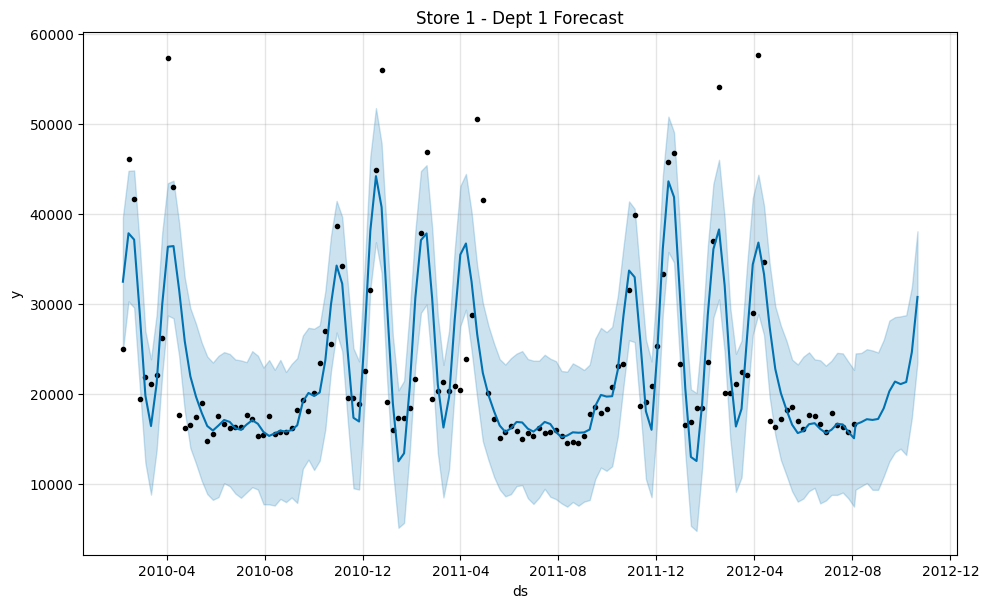

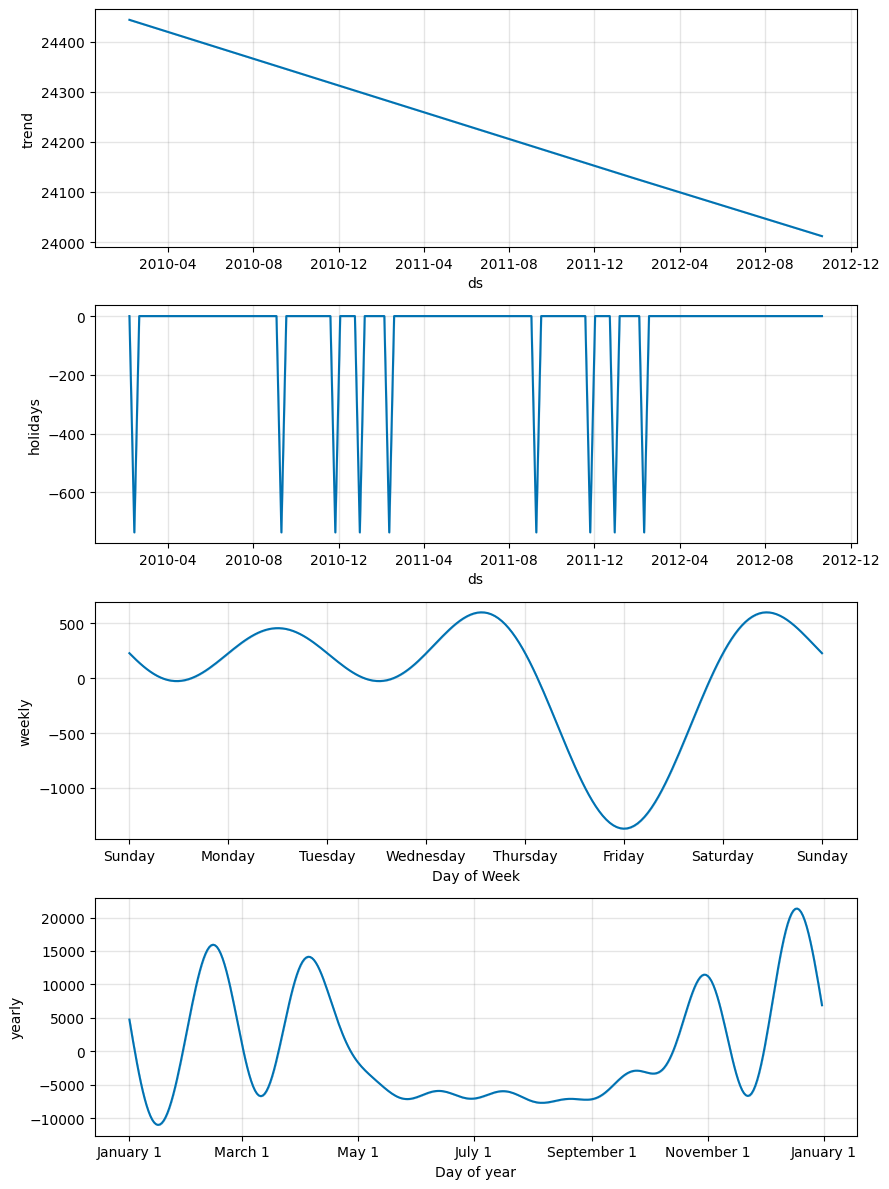

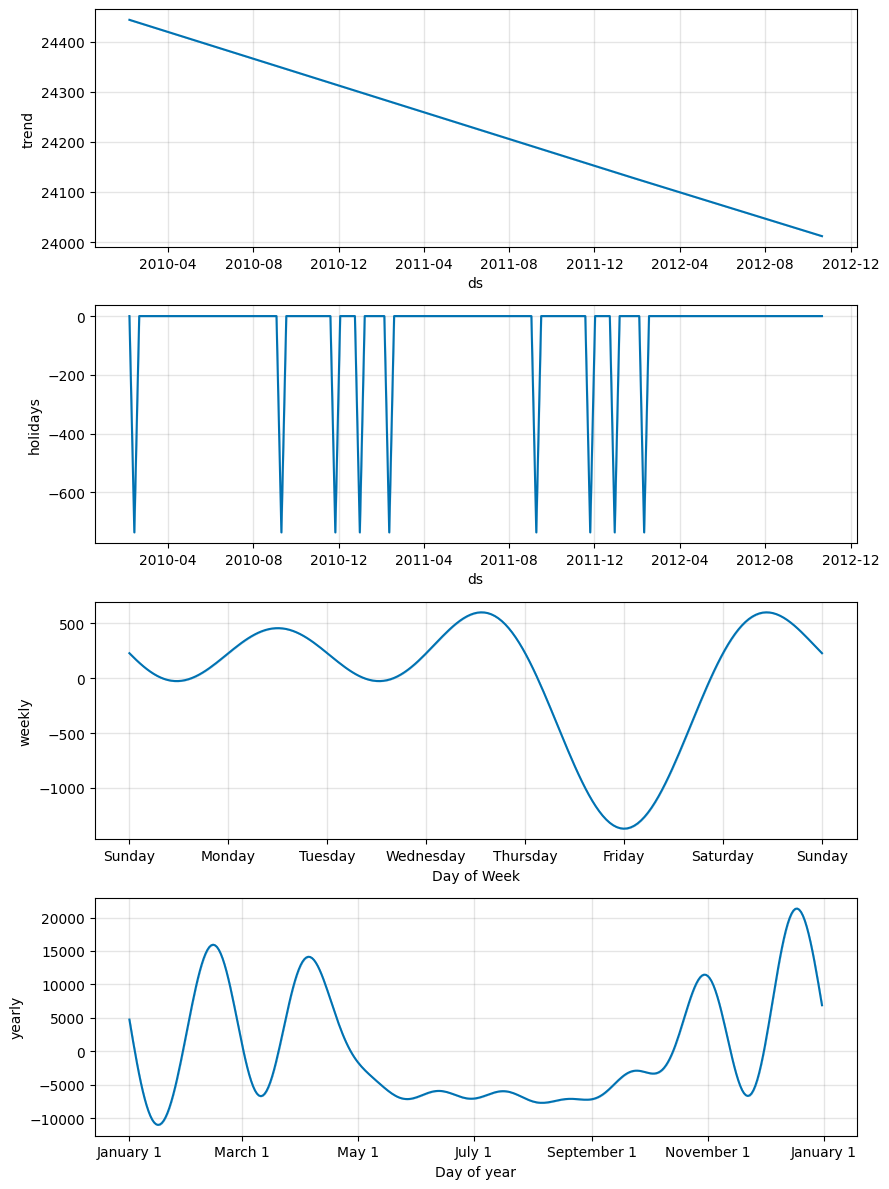

In [11]:
fig = model.plot(forecast)
plt.title(f"Store {store_id} - Dept {dept_id} Forecast")
plt.show()

model.plot_components(forecast)

In [12]:
forecasted_demand = predictions['yhat']

avg_demand = forecasted_demand.mean()
std_demand = forecasted_demand.std()

lead_time = 2  # weeks
service_level = 1.65  # 95%

safety_stock = service_level * std_demand * np.sqrt(lead_time)

reorder_point = (avg_demand * lead_time) + safety_stock

annual_demand = avg_demand * 52
ordering_cost = 100
holding_cost = 5

eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print("Average Demand:", round(avg_demand,2))
print("Safety Stock:", round(safety_stock,2))
print("Reorder Point:", round(reorder_point,2))
print("EOQ:", round(eoq,2))

Average Demand: 20226.51
Safety Stock: 9691.93
Reorder Point: 50144.95
EOQ: 6486.23


In [13]:
current_stock = 1000  # change manually

if current_stock < reorder_point:
    print("⚠ REORDER REQUIRED")
else:
    print("✅ STOCK LEVEL SAFE")

⚠ REORDER REQUIRED


In [14]:
output_df = forecast[['ds','yhat','yhat_lower','yhat_upper']]

output_df['Safety_Stock'] = safety_stock
output_df['Reorder_Point'] = reorder_point
output_df['EOQ'] = eoq

output_df.to_excel("StockSmart_Output.xlsx", index=False)

print("Excel file created successfully!")

/tmp/ipython-input-164/463291278.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_df['Safety_Stock'] = safety_stock
/tmp/ipython-input-164/463291278.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  output_df['Reorder_Point'] = reorder_point
/tmp/ipython-input-164/463291278.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas

Excel file created successfully!


In [15]:
final_output = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()

final_output.columns = [
    "Date",
    "Forecasted_Sales",
    "Lower_Bound",
    "Upper_Bound"
]

final_output.to_excel("StockSmart_Final_Output.xlsx", index=False)